In [1]:
import timeit

import matplotlib.pyplot as plt
import mpmath
import numpy as np
import pandas as pd
from matplotlib.patches import Ellipse
from scipy.special import gamma
from scipy.stats import chi2

In [2]:
# Define the Gaussian method
def random_direction(n):
    vec = np.random.normal(0, 1, n+1)
    norm = np.linalg.norm(vec)
    unit_vec = vec / norm
    return unit_vec

In [3]:
# Define the Rejection method
def random_direction_rejection(n):
    while True:
        point = np.random.uniform(-1, 1, n+1)
        if np.linalg.norm(point) <= 1:
            return point / np.linalg.norm(point)

In [4]:
# Benchmarking setup
ns = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]  # Different dimensions to test
number_of_runs = 1000  # Number of runs for each test to average out the time

benchmark_results = {}

for n in ns:
    gaussian_time = timeit.timeit('random_direction(n)', globals=globals(), number=number_of_runs)
    rejection_time = timeit.timeit('random_direction_rejection(n)', globals=globals(), number=number_of_runs)
    benchmark_results[n] = (gaussian_time, rejection_time)

benchmark_results

{1: (0.0028873999835923314, 0.004904299974441528),
 2: (0.002357299963477999, 0.006213399989064783),
 3: (0.002353799995034933, 0.009177800035104156),
 4: (0.0023713000118732452, 0.01627079996978864),
 5: (0.00238389999140054, 0.03281770000467077),
 6: (0.0023888000287115574, 0.06931700004497543),
 7: (0.0024230999988503754, 0.1634617000236176),
 8: (0.002674099989235401, 0.39405620004981756),
 9: (0.0024779000086709857, 0.9899229999864474),
 10: (0.002555799961555749, 2.848561200022232)}

In [5]:
results_df = pd.DataFrame(benchmark_results).T
results_df.columns = ['Gaussian', 'Rejection']
results_df['Ratio'] = results_df['Rejection'] / results_df['Gaussian']
results_df

,Gaussian,Rejection,Ratio
1,0.002887,0.004904,1.698518
2,0.002357,0.006213,2.635812
3,0.002354,0.009178,3.899142
4,0.002371,0.016271,6.861553
5,0.002384,0.032818,13.766391
6,0.002389,0.069317,29.017498
7,0.002423,0.163462,67.459742
8,0.002674,0.394056,147.360309
9,0.002478,0.989923,399.500786
10,0.002556,2.848561,1114.547790


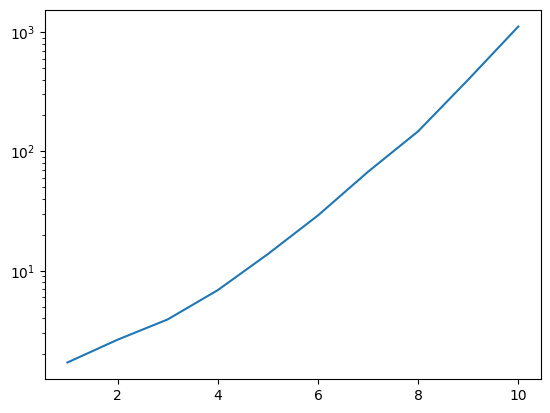

In [6]:
results_df['Ratio'].plot()
plt.yscale('log')

In [7]:
def dot_product_pdf(z, n):
    """
    Calculate the PDF of the dot product between two randomly chosen points
    on an n-sphere.
    
    Parameters:
    - z: The dot product between two points on the n-sphere.
    - n: The dimension of the sphere.
    
    Returns:
    - The value of the PDF at the given dot product z.
    """
    if z < -1 or z > 1:
        return 0  # The dot product is outside the valid range.
    coefficient = 1 / np.sqrt(np.pi) * gamma(n / 2) / gamma((n - 1) / 2)
    pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)
    return pdf_value

# Example usage:
z = 0.5  # Example dot product
n = 4    # Dimension of the sphere
pdf_value = dot_product_pdf(z, n)
print(f"PDF value for z={z} on an {n}-sphere: {pdf_value}")


PDF value for z=0.5 on an 4-sphere: 0.5513288954217921


C:\Users\oloon\AppData\Local\Temp\ipykernel_25380\1036328429.py:16: RuntimeWarning: divide by zero encountered in scalar power
  pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)
C:\Users\oloon\AppData\Local\Temp\ipykernel_25380\1036328429.py:16: RuntimeWarning: invalid value encountered in scalar multiply
  pdf_value = coefficient * (1 - z**2)**((n - 3) / 2)


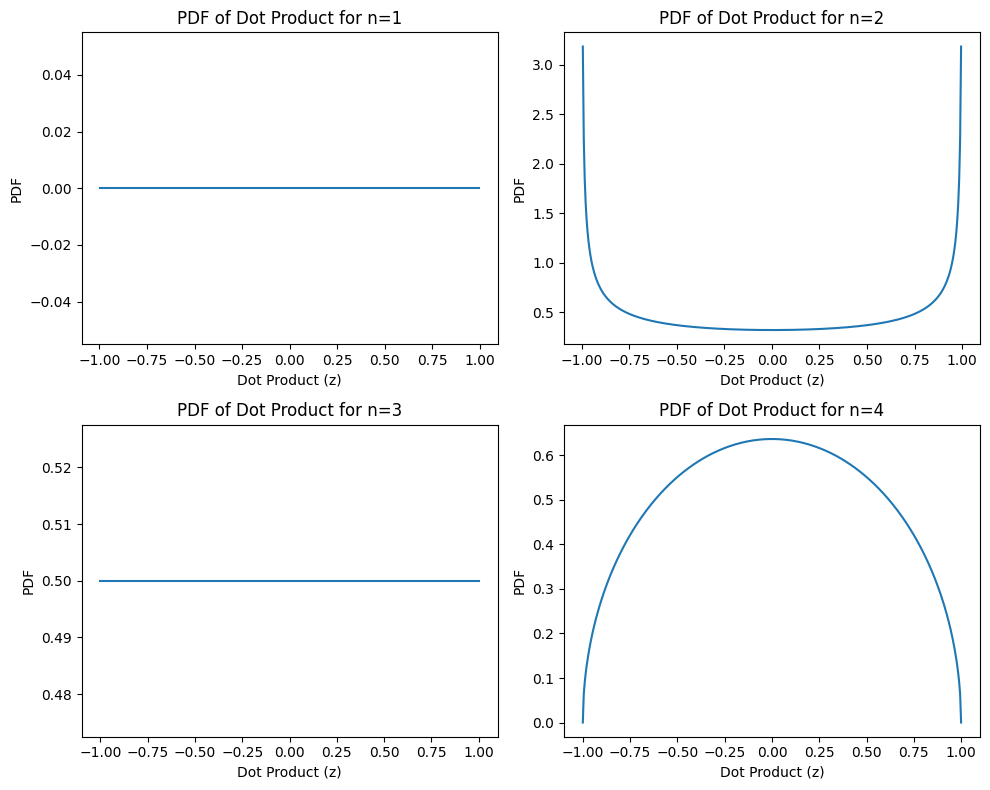

In [8]:
# Define z range
z_values = np.linspace(-1, 1, 400)

# Plot setup
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [1, 2, 3, 4]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

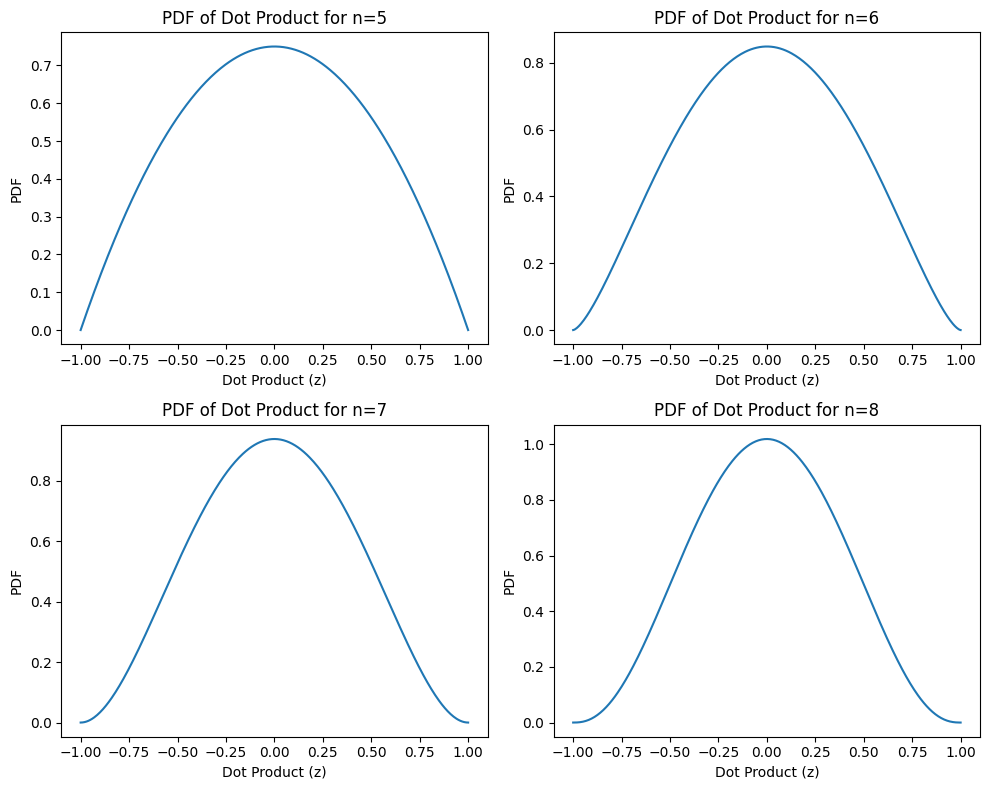

In [9]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [5, 6, 7, 8]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

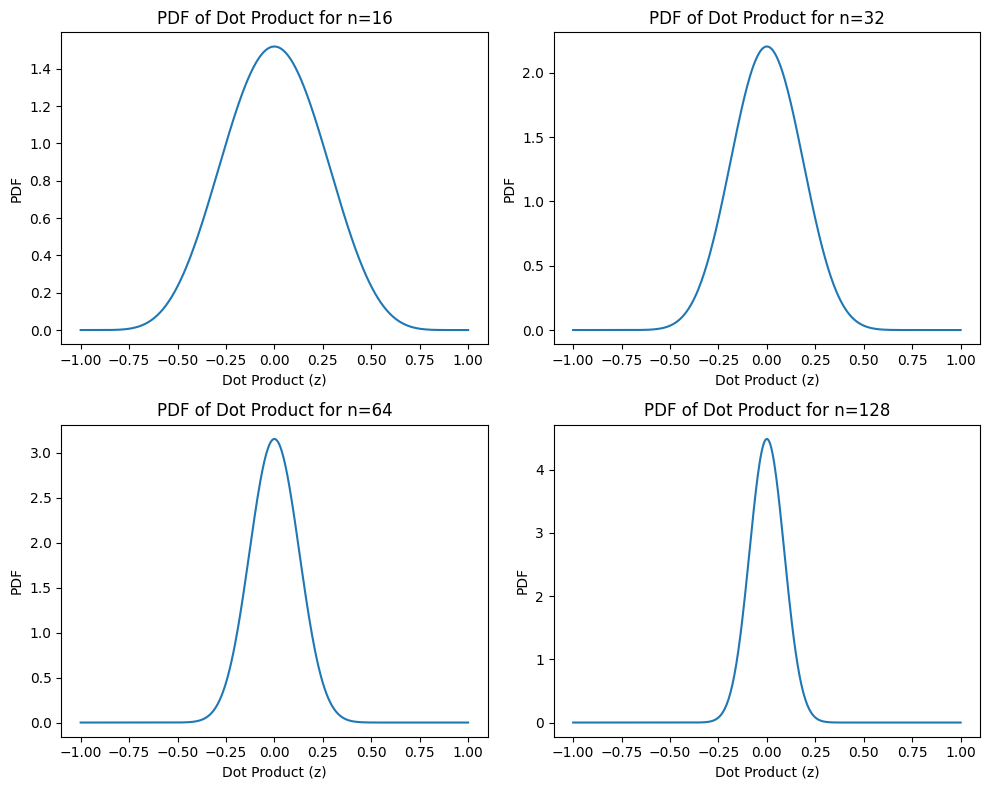

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
ns = [16, 32, 64, 128]
for i, n in enumerate(ns):
    ax = axs[i // 2, i % 2]
    pdf_values = [dot_product_pdf(z, n) for z in z_values]
    ax.plot(z_values, pdf_values, label=f'n = {n}')
    ax.set_title(f'PDF of Dot Product for n={n}')
    ax.set_xlabel('Dot Product (z)')
    ax.set_ylabel('PDF')

plt.tight_layout()
plt.show()

In [11]:
def generate_multivariate_normal_data_from_scratch(sigma, num_samples=100):
    """
    Generate synthetic data from a multivariate normal distribution using Cholesky decomposition.
    
    Parameters:
    - sigma: Covariance matrix (2D array).
    - num_samples: Number of samples to generate.
    
    Returns:
    - samples: Generated samples as a 2D array (num_samples x dimension of sigma).
    """
    # Step 1: Compute the Cholesky Decomposition of sigma
    L = np.linalg.cholesky(sigma)
    
    # Step 2: Generate standard normal samples
    dim = sigma.shape[0]  # Dimensionality of the distribution
    standard_normal_samples = np.random.normal(0, 1, (num_samples, dim))
    
    # Step 3: Transform the standard normal samples
    samples = standard_normal_samples @ L.T  # Matrix multiplication
    
    return samples

# Example usage
sigma = np.array([[1, 0.5], [0.5, 1]])  # Example covariance matrix
num_samples = 1000  # Number of samples to generate

samples = generate_multivariate_normal_data_from_scratch(sigma, num_samples)

# Display the first few samples
print(samples[:5])


[[-0.88887034  0.25075877]
 [-0.03494636 -1.40902521]
 [-0.79148515 -0.72303024]
 [ 0.40059099  0.11489959]
 [ 2.88165393  1.76985598]]


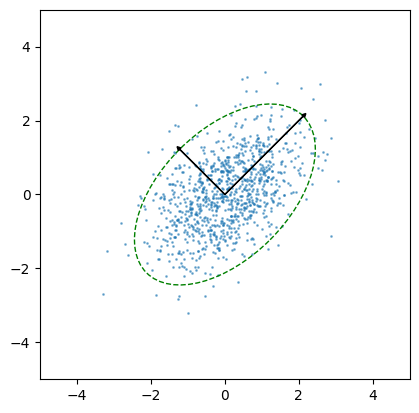

In [12]:
def g(sigma, num_samples=100):
    # sigma is a square covariance matrix
    L = np.linalg.cholesky(sigma)
    dim = sigma.shape[0]  # Dimensionality of the distribution
    standard_normal_samples = np.random.normal(0, 1, (num_samples, dim))
    samples = standard_normal_samples @ L.T  # Matrix multiplication
    return samples

def plot_samples_with_ellipse(samples, sigma, ax=None, alpha=0.95):
    """
    Plot the samples as a 2D scatterplot and add the ellipse for the given confidence interval.

    Parameters:
    - samples: Array of shape (num_samples, 2) containing the generated samples.
    - sigma: Covariance matrix of shape (2, 2).
    - ax: Matplotlib Axes object to plot on. If None, a new figure will be created.
    - alpha: Confidence interval level.
    """
    if ax is None:
        _, ax = plt.subplots()

    # Plot the samples as a scatterplot
    ax.scatter(samples[:, 0], samples[:, 1], s=1, alpha=0.5)

    # Calculate the eigenvalues and eigenvectors of the covariance matrix
    eig_vals, eig_vecs = np.linalg.eig(sigma)

    # Calculate the radius for the ellipse
    chi2_inv = chi2.ppf(alpha, df=2)
    radius = np.sqrt(chi2_inv * eig_vals)

    # Calculate the angle of rotation for the ellipse
    angle = np.degrees(np.arctan2(eig_vecs[1, 0], eig_vecs[0, 0]))

    # Create the ellipse
    ellipse = Ellipse(xy=(0, 0), width=2 * radius[0], height=2 * radius[1], angle=angle, edgecolor='g', ls='--', lw=1, fc='None')

    # Add the ellipse to the plot
    ax.add_artist(ellipse)

    # Add arrows for the eigenvectors
    arrow_scalings = np.sqrt(5.991 * eig_vals)
    for i in range(2):
        arrow_start = (0, 0)
        arrow_end = arrow_scalings[i] * eig_vecs[:, i]
        ax.arrow(*arrow_start, *arrow_end, head_width=0.1, head_length=0.1, fc='k', ec='k', linewidth=1)

    # Set the plot limits and aspect ratio
    ax.set_xlim(-5, 5)
    ax.set_ylim(-5, 5)
    ax.set_aspect('equal')

    plt.show()

# Example usage
sigma = np.array([[1, 0.5], [0.5, 1]])
num_samples = 1000
samples = g(sigma, num_samples)
plot_samples_with_ellipse(samples, sigma)

In [13]:
empirical_covariance = np.cov(samples, rowvar=False)
empirical_covariance

array([[1.01856656, 0.47119322],
       [0.47119322, 0.99117328]])

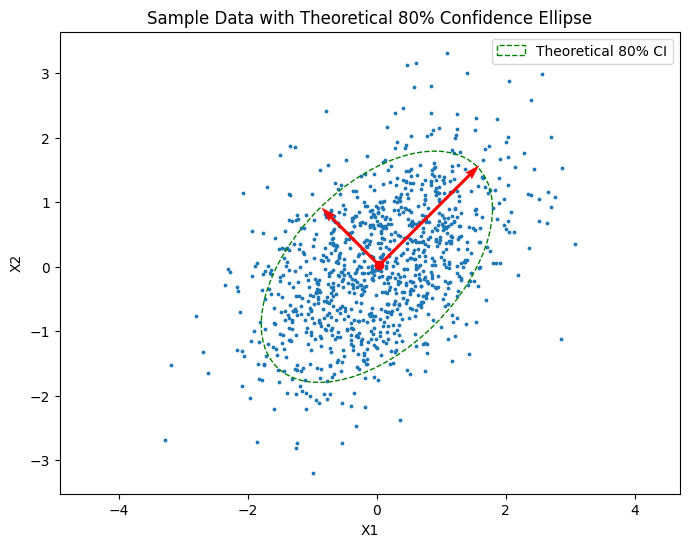

In [14]:
# 5.991 corresponds to 95% CI for 2 degrees of freedom
alpha = 0.2
chi_squared_critical_value = chi2.ppf(1-alpha, 2)

# Calculate the eigenvalues and eigenvectors of the covariance matrix
eigenvalues, eigenvectors = np.linalg.eigh(sigma)

# Calculate the angle of rotation of the ellipse
angle = np.arctan2(*eigenvectors[:, 0][::-1])

# Calculate width and height of the ellipse based on eigenvalues
# The eigenvalues give the length of the ellipse axes (square root of the eigenvalues gives the standard deviation)
width, height = 2 * np.sqrt(eigenvalues * chi_squared_critical_value)

# Create an ellipse representing the theoretical 95% CI of the distribution
ellipse = Ellipse(
    xy=(0, 0),
    width=width,
    height=height,
    angle=np.degrees(angle),
    edgecolor='g',
    linestyle='dashed',
    fc='None',
    lw=1,
    label=f'Theoretical {(1-alpha)*100:2.0f}% CI')

# Plot the sample data
plt.figure(figsize=(8, 6))
plt.scatter(samples[:, 0], samples[:, 1], s=3)

# Plot the ellipse
plt.gca().add_patch(ellipse)

# Highlight the mean of the samples
mean = np.mean(samples, axis=0)
plt.plot(mean[0], mean[1], 'ro')  # Plot the mean as a red dot

for i in range(2):
    vec_end = mean + np.sqrt(chi_squared_critical_value) * np.sqrt(eigenvalues[i]) * eigenvectors[:, i]
    plt.quiver(*mean, *(vec_end-mean), angles='xy', scale_units='xy', scale=1, color='red', width=0.005, zorder=5)
    # , label=f'$e_{i+1}$'

# Calculate fraction of points inside the ellipse
transformed_samples = (samples - mean) @ eigenvectors / np.sqrt(eigenvalues)  # Normalize by eigenvalues
distances_squared = np.sum(transformed_samples**2, axis=1)
inside_count = np.sum(distances_squared <= chi_squared_critical_value)
fraction_inside = inside_count / num_samples
fraction_inside

plt.xlabel('X1')
plt.ylabel('X2')
plt.title(f'Sample Data with Theoretical {(1-alpha)*100:2.0f}% Confidence Ellipse')
plt.legend()
plt.axis('equal')
plt.show()